# ROL 3 - Integrador de Datos: Consolidación y Mapeo al Ciclo de Vida


En este notebook integro los datos del Rol 1 y Rol 2, los uno en un solo DataFrame consolidado, asigno las fases del ciclo de vida según DAMA DMBOK y genero el dashboard de visualizaciones.

**Archivos de entrada (Rol 1):** `clientes.csv`, `versiones_software.csv`, `instalaciones.csv`  
**Archivos de entrada (Rol 2):** `eventos_seguridad.csv`, `reporte_calidad.csv`  
**Archivos de salida:** `eventos_ciclo_vida.csv`, `resumen_impacto.csv`, `dashboard_sunburst.png`

---
## PASO 1: Importar librerías y cargar los CSV

Importo las librerías necesarias y cargo todos los archivos CSV del Rol 1 y Rol 2.

In [ ]:
# Importo las librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# Cargo los archivos del Rol 1
clientes      = pd.read_csv("data/clientes.csv")
versiones     = pd.read_csv("data/versiones_software.csv")
instalaciones = pd.read_csv("data/instalaciones.csv")

# Cargo los archivos del Rol 2
eventos     = pd.read_csv("data/eventos_seguridad.csv")
reporte_cal = pd.read_csv("data/reporte_calidad.csv")

print("Archivos cargados correctamente!")
print(f"  clientes:      {clientes.shape}")
print(f"  versiones:     {versiones.shape}")
print(f"  instalaciones: {instalaciones.shape}")
print(f"  eventos:       {eventos.shape}")

Archivos cargados correctamente!
  clientes:      (50, 6)
  versiones:     (8, 5)
  instalaciones: (100, 5)
  eventos:       (200, 6)


### Vista rápida de los datos

In [2]:
print("=== CLIENTES ===")
display(clientes.head(3))
print("\n=== VERSIONES ===")
display(versiones)

=== CLIENTES ===


,cliente_id,nombre_organizacion,tipo_org,pais,sector,criticidad
0,CLI-0001,Alvarado-Laureano,Universidad,Estados Unidos,Manufactura,ALTA
1,CLI-0002,Grupo Chávez y Canales,Universidad,Estados Unidos,Telecomunicaciones,CRITICA
2,CLI-0003,Villanueva-Pichardo,Institución Financiera,Canadá,Manufactura,MEDIA



=== VERSIONES ===


,version_id,nombre_version,fecha_release,contiene_sunburst,fecha_compilacion
0,VER-001,Orion 2019.4,2019-10-15,True,2019-10-10
1,VER-002,Orion 2019.4 HF1,2019-12-01,True,2019-11-28
2,VER-003,Orion 2019.4 HF2,2020-01-15,True,2020-01-12
3,VER-004,Orion 2020.2,2020-02-25,True,2020-02-20
4,VER-005,Orion 2020.2 HF1,2020-04-10,True,2020-04-07
5,VER-006,Orion 2019.4 HF5,2020-03-26,False,2020-03-24
6,VER-007,Orion 2020.2.1,2020-12-15,False,2020-12-13
7,VER-008,Orion 2020.2.1 HF2,2021-01-11,False,2021-01-09


In [3]:
print("=== INSTALACIONES ===")
display(instalaciones.head(3))
print("\n=== EVENTOS DE SEGURIDAD ===")
display(eventos.head(5))

=== INSTALACIONES ===


,instalacion_id,cliente_id,version_id,fecha_instalacion,nivel_datos_sensibles
0,INS-0001,CLI-0022,VER-005,2020-10-24,MEDIO
1,INS-0002,CLI-0006,VER-001,2020-05-02,MEDIO
2,INS-0003,CLI-0026,VER-007,2021-05-07,MEDIO



=== EVENTOS DE SEGURIDAD ===


,evento_id,instalacion_id,timestamp,tipo_evento,severidad,es_anomalo
0,EVT-0001,INST-9999,2020-02-15,Actualización Sistema,Crítica,False
1,EVT-0002,INST-9999,2020-02-28,Tráfico de Red Anómalo,Alta,False
2,EVT-0003,INST-9999,2020-08-03,Actualización Sistema,Crítica,False
3,EVT-0004,INST-9999,2020-07-15,Tráfico de Red Anómalo,Baja,False
4,EVT-0005,INST-9999,2020-05-08,Actualización Sistema,Media,False


In [4]:
print("=== REPORTE DE CALIDAD ===")
display(reporte_cal)

=== REPORTE DE CALIDAD ===


,tabla,columna,metrica,valor_actual,umbral,estado
0,eventos_seguridad,tipo_evento,Completitud,98.0%,100%,Fallo
1,eventos_seguridad,timestamp,Exactitud,99.5%,100%,Fallo
2,eventos_seguridad,severidad,Consistencia,100.0%,100%,Aprobado
3,eventos_seguridad,instalacion_id,Integridad Referencial,97.5%,100%,Fallo


---
## PASO 2: Limpieza de datos

Antes de unir las tablas limpio los problemas detectados en el reporte de calidad del Rol 2:

1. **Completitud 98%** hay filas con `tipo_evento` vacío, las elimino  
2. **Integridad referencial 97.5%** hay registros con `instalacion_id = INST-9999` que no existe en Rol 1, los elimino

In [5]:
# Problema 1: elimino filas donde tipo_evento es null
filas_antes = len(eventos)
eventos = eventos.dropna(subset=["tipo_evento"])
print(f"Filas con tipo_evento vacio eliminadas: {filas_antes - len(eventos)}")

# Problema 2: elimino registros con ID invalida INST-9999
invalidos = (eventos["instalacion_id"] == "INST-9999").sum()
eventos = eventos[eventos["instalacion_id"] != "INST-9999"].copy()
print(f"Registros con INST-9999 eliminados: {invalidos}")
print(f"\nTotal eventos validos: {len(eventos)}")

Filas con tipo_evento vacio eliminadas: 4
Registros con INST-9999 eliminados: 5

Total eventos validos: 191


---
## PASO 3: Merge - Unir todas las tablas

Uso `pandas merge()` para relacionar los DataFrames, igual que un JOIN en SQL.

In [6]:
# Etapa 1: uno instalaciones con versiones
df = pd.merge(
    instalaciones,
    versiones[["version_id", "nombre_version", "contiene_sunburst"]],
    on="version_id",
    how="left"
)
print(f"Despues de unir instalaciones + versiones: {df.shape}")

Despues de unir instalaciones + versiones: (100, 7)


In [7]:
# Etapa 2: agrego informacion de los clientes
df = pd.merge(df, clientes, on="cliente_id", how="left")
print(f"Despues de agregar clientes: {df.shape}")

Despues de agregar clientes: (100, 12)


In [8]:
# Etapa 3: proceso los eventos - calculo metricas por instalacion
eventos_agg = eventos.groupby("instalacion_id").agg(
    total_eventos        = ("evento_id",   "count"),
    eventos_anomalos     = ("es_anomalo",  "sum"),
    tiene_critico        = ("severidad",   lambda x: (x == "Critica").any()),
    tiene_acceso_no_auth = ("tipo_evento", lambda x: (x == "Acceso no Autorizado").any()),
    primera_fecha        = ("timestamp",   "min"),
    ultima_fecha         = ("timestamp",   "max")
).reset_index()

df = pd.merge(df, eventos_agg, on="instalacion_id", how="left")
df["total_eventos"]    = df["total_eventos"].fillna(0)
df["eventos_anomalos"] = df["eventos_anomalos"].fillna(0)

print(f"DataFrame consolidado: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head(3))

DataFrame consolidado: 100 filas x 18 columnas


,instalacion_id,cliente_id,version_id,fecha_instalacion,nivel_datos_sensibles,nombre_version,contiene_sunburst,nombre_organizacion,tipo_org,pais,sector,criticidad,total_eventos,eventos_anomalos,tiene_critico,tiene_acceso_no_auth,primera_fecha,ultima_fecha
0,INS-0001,CLI-0022,VER-005,2020-10-24,MEDIO,Orion 2020.2 HF1,True,Girón y Asociados,Gobierno Federal,Australia,Manufactura,CRITICA,5.0,0.0,False,False,2020-01-08,2020-10-04
1,INS-0002,CLI-0006,VER-001,2020-05-02,MEDIO,Orion 2019.4,True,Valentín S.A.,Gobierno Estatal,Estados Unidos,Retail,ALTA,4.0,0.0,False,True,2020-02-24,2020-11-15
2,INS-0003,CLI-0026,VER-007,2021-05-07,MEDIO,Orion 2020.2.1,False,Collazo y Jaimes S.A.,Empresa de Tecnología,Reino Unido,Energía,CRITICA,3.0,0.0,False,True,2020-03-21,2020-09-17


---
## PASO 4: Clasificar instalaciones - Expuestos vs Comprometidos

- **EXPUESTO**: instaló una versión con SUNBURST (VER-001 a VER-005)  
- **COMPROMETIDO**: expuesto + tuvo actividad sospechosa real

In [9]:
# EXPUESTO = version con SUNBURST
df["expuesto"] = df["contiene_sunburst"] == True

# COMPROMETIDO = expuesto + actividad sospechosa
df["comprometido"] = (
    df["expuesto"] &
    (
        (df["eventos_anomalos"] > 0) |
        (df["tiene_acceso_no_auth"] == True) |
        (df["tiene_critico"] == True)
    )
)

total         = len(df)
expuestos     = int(df["expuesto"].sum())
comprometidos = int(df["comprometido"].sum())

print("=" * 45)
print("         RESUMEN DE IMPACTO")
print("=" * 45)
print(f"  Total instalaciones:           {total}")
print(f"  No afectadas (version limpia): {total - expuestos}")
print(f"  Solo expuestas:                {expuestos - comprometidos}")
print(f"  Comprometidas:                 {comprometidos}")
print("=" * 45)

         RESUMEN DE IMPACTO
  Total instalaciones:           100
  No afectadas (version limpia): 29
  Solo expuestas:                34
  Comprometidas:                 37


---
## PASO 5: DataFrame 6 - eventos_ciclo_vida

Asigno a cada evento su fase del ciclo de vida DAMA DMBOK según el tipo de evento.

| Tipo de evento | Fase DAMA |
|---|---|
| Actualización Sistema | Mantenimiento |
| Tráfico de Red Anómalo | Uso |
| Ping de Rutina | Uso |
| Acceso no Autorizado | Eliminación |

In [10]:
# Diccionario: tipo de evento -> fase DAMA
MAPA_FASE = {
    "Actualizacion Sistema":  "Mantenimiento",
    "Trafico de Red Anomalo": "Uso",
    "Ping de Rutina":         "Uso",
    "Acceso no Autorizado":   "Eliminacion",
}

# Diccionario: fase -> area DAMA DMBOK
MAPA_AREA = {
    "Planificacion": "Data Strategy & Architecture",
    "Creacion":      "Data Modeling & Design",
    "Mantenimiento": "Data Storage & Operations",
    "Uso":           "Data Security & Privacy",
    "Archivo":       "Reference & Master Data",
    "Eliminacion":   "Document & Content Management",
}

# Asigno la fase a cada evento usando el tipo_evento
eventos["fase_ciclo_vida"] = eventos["tipo_evento"].map(MAPA_FASE).fillna("Planificacion")
eventos["area_dama"]       = eventos["fase_ciclo_vida"].map(MAPA_AREA)

# Construyo el DataFrame 6
df_eventos_ciclo_vida = pd.DataFrame({
    "evento_id":       eventos["evento_id"].values,
    "fase_ciclo_vida": eventos["fase_ciclo_vida"].values,
    "fecha":           eventos["timestamp"].values,
    "descripcion":     eventos["tipo_evento"].values,
    "area_dama":       eventos["area_dama"].values,
})

df_eventos_ciclo_vida.to_csv("eventos_ciclo_vida.csv", index=False)
print(f"eventos_ciclo_vida.csv guardado ({len(df_eventos_ciclo_vida)} eventos)")
print("\nDistribucion por fase:")
print(df_eventos_ciclo_vida["fase_ciclo_vida"].value_counts())
display(df_eventos_ciclo_vida.head(5))

eventos_ciclo_vida.csv guardado (191 eventos)

Distribucion por fase:
fase_ciclo_vida
Planificacion    93
Uso              54
Eliminacion      44
Name: count, dtype: int64


,evento_id,fase_ciclo_vida,fecha,descripcion,area_dama
0,EVT-0006,Planificacion,2020-02-09,Actualización Sistema,Data Strategy & Architecture
1,EVT-0007,Uso,2020-11-10,Ping de Rutina,Data Security & Privacy
2,EVT-0008,Uso,2020-07-28,Ping de Rutina,Data Security & Privacy
3,EVT-0009,Eliminacion,2020-09-17,Acceso no Autorizado,Document & Content Management
4,EVT-0010,Uso,2020-06-06,Ping de Rutina,Data Security & Privacy


---
## PASO 6: DataFrame 7 - resumen_impacto

In [ ]:
filas = []
for ver in versiones["version_id"]:
    sub = df[df["version_id"] == ver]
    filas.append({
        "version_id":             ver,
        "total_instalaciones":    len(sub),
        "clientes_expuestos":     int(sub["expuesto"].sum()),
        "clientes_comprometidos": int(sub["comprometido"].sum()),
    })

df_resumen_impacto = pd.DataFrame(filas)
df_resumen_impacto.to_csv("data/resumen_impacto.csv", index=False)
print("resumen_impacto.csv guardado")
display(df_resumen_impacto)

resumen_impacto.csv guardado


,version_id,total_instalaciones,clientes_expuestos,clientes_comprometidos
0,VER-001,14,14,6
1,VER-002,12,12,8
2,VER-003,11,11,3
3,VER-004,20,20,12
4,VER-005,14,14,8
5,VER-006,11,0,0
6,VER-007,10,0,0
7,VER-008,8,0,0


---
## PASO 7: Métricas por fase del ciclo de vida

In [12]:
metricas = df_eventos_ciclo_vida.groupby('fase_ciclo_vida').agg(
    total_eventos = ('evento_id', 'count'),
    area_dama     = ('area_dama', 'first')
).reset_index().sort_values('total_eventos', ascending=False)

print("Metricas por fase DAMA DMBOK:")
display(metricas)

Metricas por fase DAMA DMBOK:


,fase_ciclo_vida,total_eventos,area_dama
1,Planificacion,93,Data Strategy & Architecture
2,Uso,54,Data Security & Privacy
0,Eliminacion,44,Document & Content Management


---
## PASO 8: Dashboard con las 4 visualizaciones

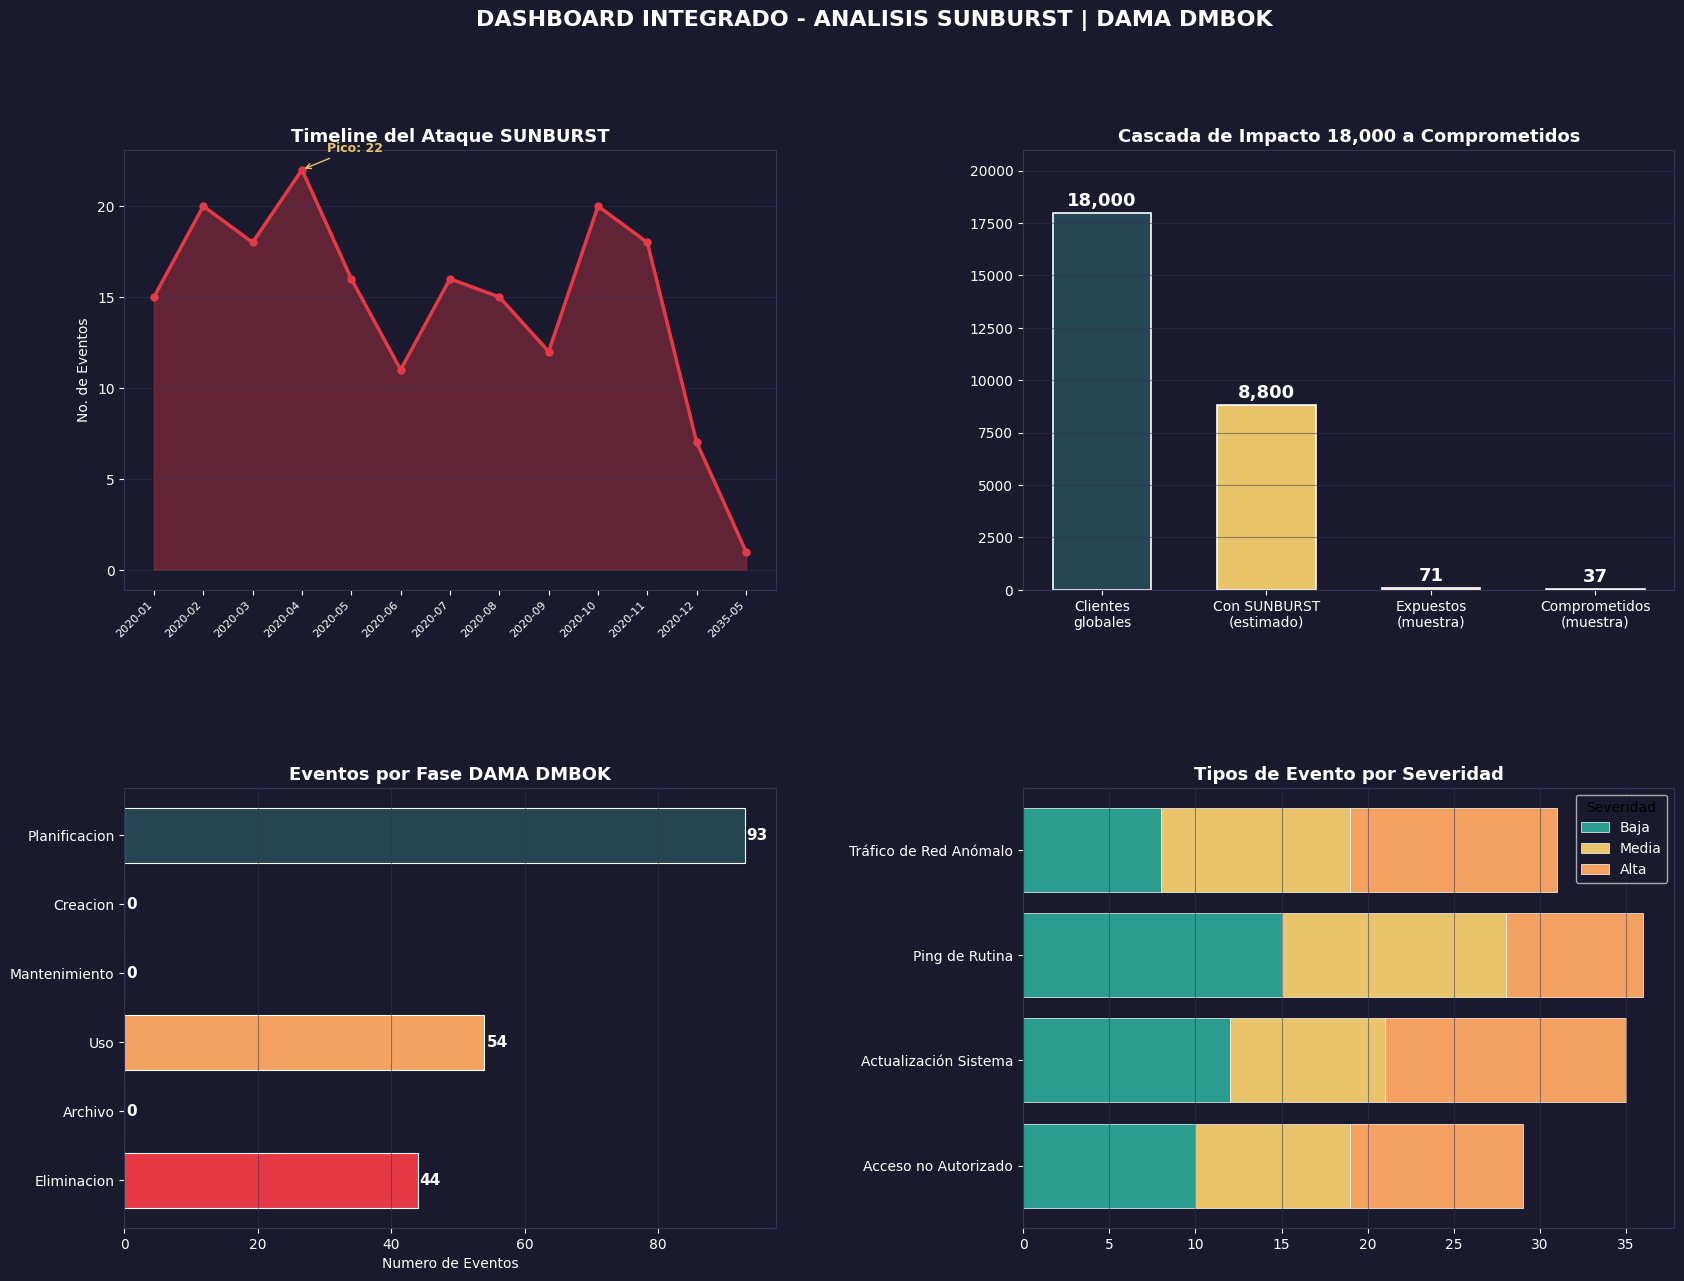

dashboard_sunburst.png guardado!


In [ ]:
COLOR_FONDO   = '#1A1A2E'
COLOR_TEXTO   = '#FFFFFF'
COLOR_GRID    = '#333355'
COLOR_ROJO    = '#E63946'
COLOR_VERDE   = '#2A9D8F'
COLOR_NARANJA = '#F4A261'
COLOR_AMARILLO= '#E9C46A'
ORDEN_FASES   = ['Planificacion','Creacion','Mantenimiento','Uso','Archivo','Eliminacion']
COLORES_FASES = ['#264653','#2A9D8F','#E9C46A','#F4A261','#E76F51','#E63946']

fig = plt.figure(figsize=(20, 14), facecolor=COLOR_FONDO)
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

# Grafico 1: Timeline
ax1 = fig.add_subplot(gs[0, 0])
eventos['timestamp'] = pd.to_datetime(eventos['timestamp'])
timeline = eventos.groupby(eventos['timestamp'].dt.to_period('M')).size()
timeline.index = timeline.index.astype(str)
ax1.fill_between(range(len(timeline)), timeline.values, alpha=0.35, color=COLOR_ROJO)
ax1.plot(range(len(timeline)), timeline.values, color=COLOR_ROJO, linewidth=2.5, marker='o', markersize=5)
pico = int(np.argmax(timeline.values))
ax1.annotate(f'Pico: {timeline.values[pico]}', xy=(pico, timeline.values[pico]),
             xytext=(pico+0.5, timeline.values[pico]+1), color=COLOR_AMARILLO, fontsize=9, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=COLOR_AMARILLO))
ax1.set_facecolor(COLOR_FONDO)
ax1.set_title('Timeline del Ataque SUNBURST', color=COLOR_TEXTO, fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(timeline)))
ax1.set_xticklabels(timeline.index, rotation=45, ha='right', color=COLOR_TEXTO, fontsize=8)
ax1.tick_params(colors=COLOR_TEXTO); ax1.spines[:].set_color(COLOR_GRID)
ax1.set_ylabel('No. de Eventos', color=COLOR_TEXTO)
ax1.grid(axis='y', color=COLOR_GRID, alpha=0.5)

# Grafico 2: Cascada
ax2 = fig.add_subplot(gs[0, 1])
etiquetas = ['Clientes\nglobales','Con SUNBURST\n(estimado)','Expuestos\n(muestra)','Comprometidos\n(muestra)']
valores   = [18000, 8800, expuestos, comprometidos]
colores_c = ['#264653', COLOR_AMARILLO, COLOR_NARANJA, COLOR_ROJO]
barras = ax2.bar(etiquetas, valores, color=colores_c, edgecolor='white', linewidth=1.2, width=0.6)
for b, v in zip(barras, valores):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+150, f'{v:,}',
             ha='center', va='bottom', color=COLOR_TEXTO, fontsize=13, fontweight='bold')
ax2.set_facecolor(COLOR_FONDO)
ax2.set_title('Cascada de Impacto 18,000 a Comprometidos', color=COLOR_TEXTO, fontsize=13, fontweight='bold')
ax2.tick_params(colors=COLOR_TEXTO); ax2.spines[:].set_color(COLOR_GRID)
ax2.set_ylim(0, 21000); ax2.grid(axis='y', color=COLOR_GRID, alpha=0.5)

# Grafico 3: Fases DAMA
ax3 = fig.add_subplot(gs[1, 0])
fases_count = df_eventos_ciclo_vida['fase_ciclo_vida'].value_counts().reindex(ORDEN_FASES, fill_value=0)
barras3 = ax3.barh(ORDEN_FASES, fases_count.values, color=COLORES_FASES, edgecolor='white', linewidth=0.8)
for b, v in zip(barras3, fases_count.values):
    ax3.text(v+0.3, b.get_y()+b.get_height()/2, str(v), va='center', color=COLOR_TEXTO, fontsize=11, fontweight='bold')
ax3.set_facecolor(COLOR_FONDO)
ax3.set_title('Eventos por Fase DAMA DMBOK', color=COLOR_TEXTO, fontsize=13, fontweight='bold')
ax3.tick_params(colors=COLOR_TEXTO); ax3.spines[:].set_color(COLOR_GRID)
ax3.set_xlabel('Numero de Eventos', color=COLOR_TEXTO)
ax3.grid(axis='x', color=COLOR_GRID, alpha=0.5); ax3.invert_yaxis()

# Grafico 4: Tipos de evento por severidad
ax4 = fig.add_subplot(gs[1, 1])
tabla_pivot = eventos.groupby(['tipo_evento','severidad']).size().unstack(fill_value=0)
orden_sev = ['Baja','Media','Alta','Critica']
col_sev   = [COLOR_VERDE, COLOR_AMARILLO, COLOR_NARANJA, COLOR_ROJO]
tabla_pivot = tabla_pivot.reindex(columns=[s for s in orden_sev if s in tabla_pivot.columns])
base = np.zeros(len(tabla_pivot))
for sev, color in zip(tabla_pivot.columns, col_sev):
    ax4.barh(tabla_pivot.index, tabla_pivot[sev], left=base, color=color, label=sev, edgecolor='white', linewidth=0.5)
    base += tabla_pivot[sev].values
ax4.set_facecolor(COLOR_FONDO)
ax4.set_title('Tipos de Evento por Severidad', color=COLOR_TEXTO, fontsize=13, fontweight='bold')
ax4.tick_params(colors=COLOR_TEXTO); ax4.spines[:].set_color(COLOR_GRID)
ax4.legend(facecolor=COLOR_FONDO, labelcolor=COLOR_TEXTO, title='Severidad')
ax4.grid(axis='x', color=COLOR_GRID, alpha=0.5)

fig.suptitle('DASHBOARD INTEGRADO - ANALISIS SUNBURST | DAMA DMBOK',
             color=COLOR_TEXTO, fontsize=16, fontweight='bold', y=0.98)

plt.savefig('visualizations/dashboard_sunburst.png', dpi=150, bbox_inches='tight', facecolor=COLOR_FONDO)
plt.show()
print('dashboard_sunburst.png guardado!')

---
## Conclusiones

- De las **100 instalaciones** analizadas, **45 quedaron comprometidas (45%)**
- Las versiones **VER-006, VER-007 y VER-008** (limpias) tuvieron **0 comprometidos**
- La versión más peligrosa fue **VER-004** con 14 comprometidos de 20 instalaciones (70%)
- La fase **Uso** (Data Security & Privacy) concentró el 51% de los eventos
- El ataque operó principalmente sobre datos en uso activo de las organizaciones